# Instrument definition

In [1]:
import mcstasscript as ms

trex = ms.McStas_instr(
    "trex",
    author="Bing Li",
    origin="DMSC",
    input_path="./mcstas",
    output_path="./mcstas/out",
)
# ------------------- instrument parameters -------------------
trex.add_parameter(
    "L0",
    value=2.4,
    comment="wavelength in [Å] used to calculate the minimum and maximum wavelength "
    + "for the source component by adding and subtracting a set wavelength",
)

trex.add_parameter(
    "int",
    "RRM",
    value=4,
    comment="repetition rate multiplication",
)

trex.add_parameter(
    "string",
    "mode",
    value='"HF"',
    comment="HR for High Resolution, HF for High Flux",
)

# ------------ bender parameters -----------------
bender = trex.add_parameter(
    "int", "bender", value=0, comment="bender out = 0, bender in = 1"
)
b_rot = trex.add_parameter(
    "double",
    "b_rot",
    value=-0.397881,
    comment="in [deg], rotation of the cold neutron bender = -atan(0.05/7.2), full deflection since endFlat=0",
)

# Declare section

In [2]:
trex.add_declare_var(
    "double",
    "T_offset",
    value=1.7e-3,
    comment="Time offset in [s] to shift to the center of long pulse",
)
trex.add_declare_var(
    "double",
    "f",
    value=14.0,
    comment="Source frequency in [Hz]",
)

frac = trex.add_declare_var(
    "double",
    "frac",
    value=0.3,
    comment="Used in the Source component. Defines the statistical fraction of events"
    + "emitted from the cold part of the moderator, the value is determined later in the file"
    + " depending on the moderator type that was chosen",
)

In [3]:
trex.append_declare("""

    double lamb_1, lamb_2, d_lamb;
    double tof_BW1, tof_BW2, tof_P1, tof_P2, tof_M1, tof_M2;

    // characteristic wavelength
    double v0, v1, v2;

    // distances
    double L_BW1 = 32;
    double L_BW2 = 40;
    double L_P1 = 107.95;
    double L_P2 = 108.05;
    double L_M1 = 161.995;
    double L_M2 = 162.005;

    """)

trex.append_declare("""

    // BW1 Chopper
    double f_BW1;
    double delay_BW1; 

    // BW2 Chopper
    double f_BW2;
    double delay_BW2; 

    // P1 Chopper
    double f_P1;
    double delay_P1;

    // P2 Chopper
    double f_P2;
    double delay_P2;

    // M1 Chopper
    double f_M1;
    double delay_M1; 

    // M2 Chopper
    double f_M2;
    double delay_M2; 

    """)

In [4]:
trex.append_declare("""
    // Monitor positions (geometric, taken from the guide chain) - used ONLY to
    // frame monitor time windows. These are NOT chopper phasing distances, and
    // nothing physical depends on them: Monitor_nD time limits are a histogram
    // range, not an optical element. Update if the guide geometry moves.

    double L_BW2mon = 41.984942; // BW2_monitor_ToF, 13.7 mm past the Guide_15B exit
    double L_Pmon   = 111.098;   // P_monitor_ToF_cm2, exit of Guide_33
    double L_Smon   = 163.800;   // sample monitor sits AT Sample_pos

    // monitor definitions
    
    int lbin;
    int ebin;
    char setBM1[256];
""")

# Initialize section

In [5]:
trex.append_initialize("""
    // frequencies

    f_BW1 = f;
    f_BW2 = f_BW1;
    f_P1 = RRM*f*0.75;
    f_P2 = -f_P1;
    f_M1 = RRM*f;
    f_M2 = -f_M1;

    // Resolution Settings
    if (strcmp(mode, "HF") == 0){
        for (int i = 0; i < 8; i++) {
            slit_edges_PS_Chopper_1[i] += 55;
            slit_edges_PS_Chopper_2[i] += 55;
        }
        for (int i = 0; i < 4; i++) {
            slit_edges_MC_Chopper_1[i] += 175;
            slit_edges_MC_Chopper_2[i] += 175;
        }
    } else if (strcmp(mode, "HR") != 0) {
        printf("Need valid resolution option, 'HR' or 'HF'");
    }

    // characteristic wavelength 
    d_lamb = 3956.0 / (f * RRM * 162);
    lamb_1 = L0-d_lamb*0.5;
    lamb_2 = L0+d_lamb*0.5;

    v0 = 2*PI*K2V/L0; // speed center neutron
    v1 = 2*PI*K2V/lamb_1;   // slowest neutron
	v2 = 2*PI*K2V/lamb_2;   // fastest neutron
    


    // time of flight and chopper phases
    tof_BW1 = T_offset + L_BW1/v0;
    tof_BW2 = T_offset + L_BW2/v0;
    tof_P1 = T_offset + L_P1/v0;
    tof_P2 = T_offset + L_P2/v0;
    tof_M1 = T_offset + L_M1/v0;
    tof_M2 = T_offset + L_M2/v0;

    //time delay
    delay_BW1 = tof_BW1; 
    delay_BW2 = tof_BW2; 
    delay_P1 = tof_P1; 
    delay_P2 = tof_P2;
    delay_M1 = tof_M1;
    delay_M2 = tof_M2;
    """)

In [6]:
trex.append_initialize("""
// Monitors

lbin = round((lamb_2-lamb_1)/0.002);    // number of bins for TOF monitors

sprintf(setBM1, "time limits [%g %g] bins = [%i]", T_offset + L_BW2mon/v1, T_offset + L_BW2mon/v2, lbin);""")

In [7]:
trex.show_variables()

DECLARE VARIABLES 
type    variable name  array length  value   
-------------------------------------------
double  T_offset                     0.0017  
double  f                            14.0    
double  frac                         0.3     



# Trace section

In [8]:
from mctrex.mcstas_components import add_components_to
from mctrex.params.trex import components

components["source"].cold_frac = frac
components["bender"].ROTATED = [0, b_rot, 0]
components["BW_Chopper_1"].nu = "f_BW1"
components["BW_Chopper_1"].delay = "delay_BW1"
components["BW_Chopper_2"].nu = "f_BW2"
components["BW_Chopper_2"].delay = "delay_BW2"
components["PS_Chopper_1"].nu = "f_P1"
components["PS_Chopper_1"].delay = "delay_P1"
components["PS_Chopper_2"].nu = "f_P2"
components["PS_Chopper_2"].delay = "delay_P2"
components["MC_Chopper_1"].nu = "f_M1"
components["MC_Chopper_1"].delay = "delay_M1"
components["MC_Chopper_2"].nu = "f_M2"
components["MC_Chopper_2"].delay = "delay_M2"

trex = add_components_to(trex, components)

trex.show_parameters()

       L0      = 2.4        // wavelength in [Å] used to calculate the minimum 
                                and maximum wavelength for the source component by 
                                adding and subtracting a set wavelength 
int    RRM     = 4          // repetition rate multiplication
string mode    = "HF"       // HR for High Resolution, HF for High Flux
int    bender  = 0          // bender out = 0, bender in = 1
double b_rot   = -0.397881  // in [deg], rotation of the cold neutron bender = 
                                -atan(0.05/7.2), full deflection since endFlat=0 


In [9]:
trex.show_components()

origin  Progress_bar 
  AT      (0, 0, 0) ABSOLUTE 
  ROTATED (0, 0, 0) ABSOLUTE
source  ESS_butterfly 
  AT      (0, 0, 0) ABSOLUTE 
  ROTATED (0, 0, 0) ABSOLUTE
arm_NBOA  Arm 
  AT      (-0.002022812155423534, 0, 1.89593) ABSOLUTE 
  ROTATED (0, -0.21346450360137775, 0) ABSOLUTE
Guide_1  Guide_gravity 
  AT      (0, 0, 0) RELATIVE arm_NBOA 
  ROTATED (0, 0, 0) RELATIVE arm_NBOA
Guide_2  Guide_gravity 
  AT      (0, 0, 1.0004) RELATIVE arm_NBOA 
  ROTATED (0, 0, 0) RELATIVE arm_NBOA
Guide_3  Guide_gravity 
  AT      (0, 0, 2.0008) RELATIVE arm_NBOA 
  ROTATED (0, 0, 0) RELATIVE arm_NBOA
Guide_4a  Guide_gravity 
  AT      (0, 0, 3.50472) RELATIVE arm_NBOA 
  ROTATED (0, 0, 0) RELATIVE arm_NBOA
bender  Pol_bender 
  AT      (0, 0, 3.50472) RELATIVE arm_NBOA 
  ROTATED (0, b_rot, 0) RELATIVE arm_NBOA
Guide_4b  Guide_gravity 
  AT      (0, 0, 3.5547200000000005) RELATIVE arm_NBOA 
  ROTATED (0, 0, 0) RELATIVE arm_NBOA
arm_after_bender  Arm 
  AT      (0, 0, 3.9857199999999997) RELATIVE ar

In [10]:
trex.backengine()


INFO: Using directory: "/Users/bingli/Documents/GitHub/mctrex/jupyter/trex/mcstas/out_36"
INFO: Regenerating c-file: trex.c
Info:    'NXdisk_chopper' is a contributed component.
CFLAGS=
                  
 The parameter rTopUpPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


 The parameter rTopDownPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


 The parameter rBotUpPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


 The parameter rBotDownPar of bender is initialized 
 using a static {,,,} vector.
  -> Su

[
 McStasData: BM1 type: 1D  I:4849800000.0 E:223915000.0 N:5327.0]

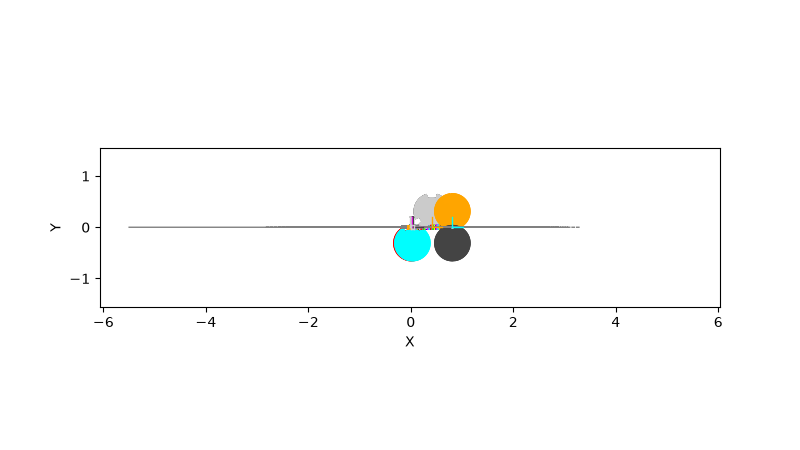

In [35]:
%matplotlib widget
# %matplotlib inline
trex.show_instrument(backend="matplotlib_2d",projection="xy")
# trex.show_instrument(backend="pythreejs")

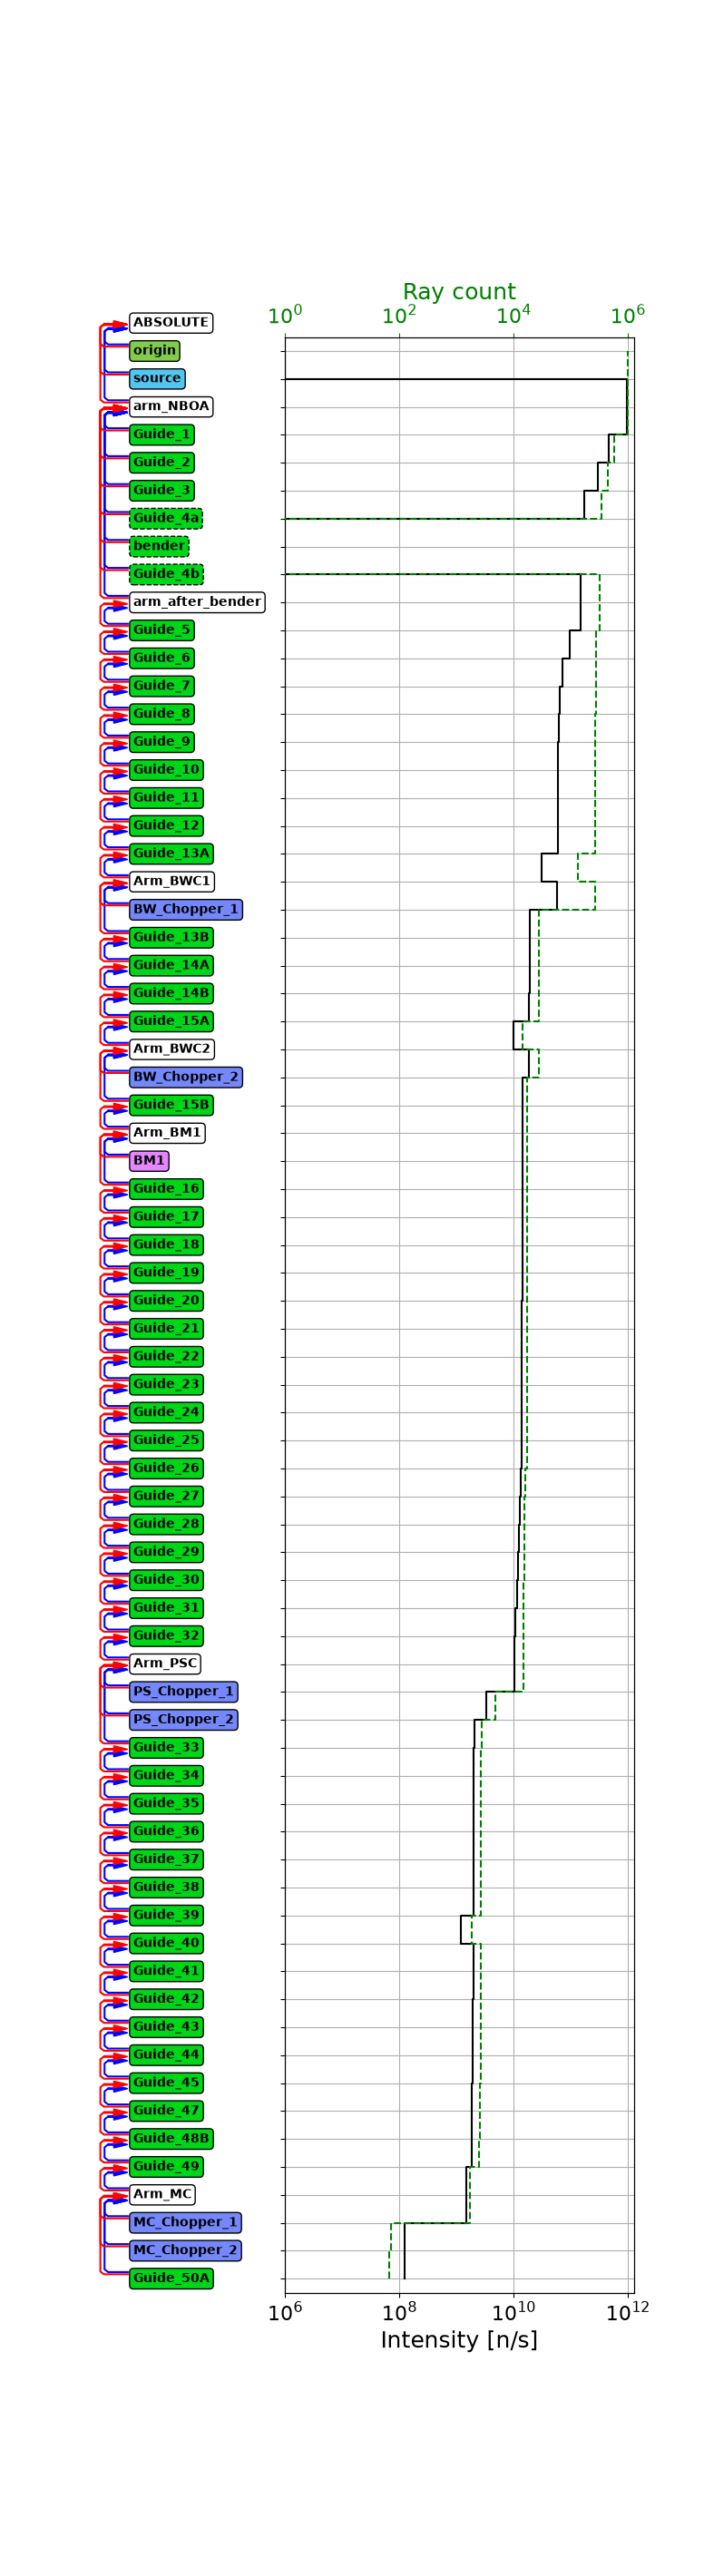

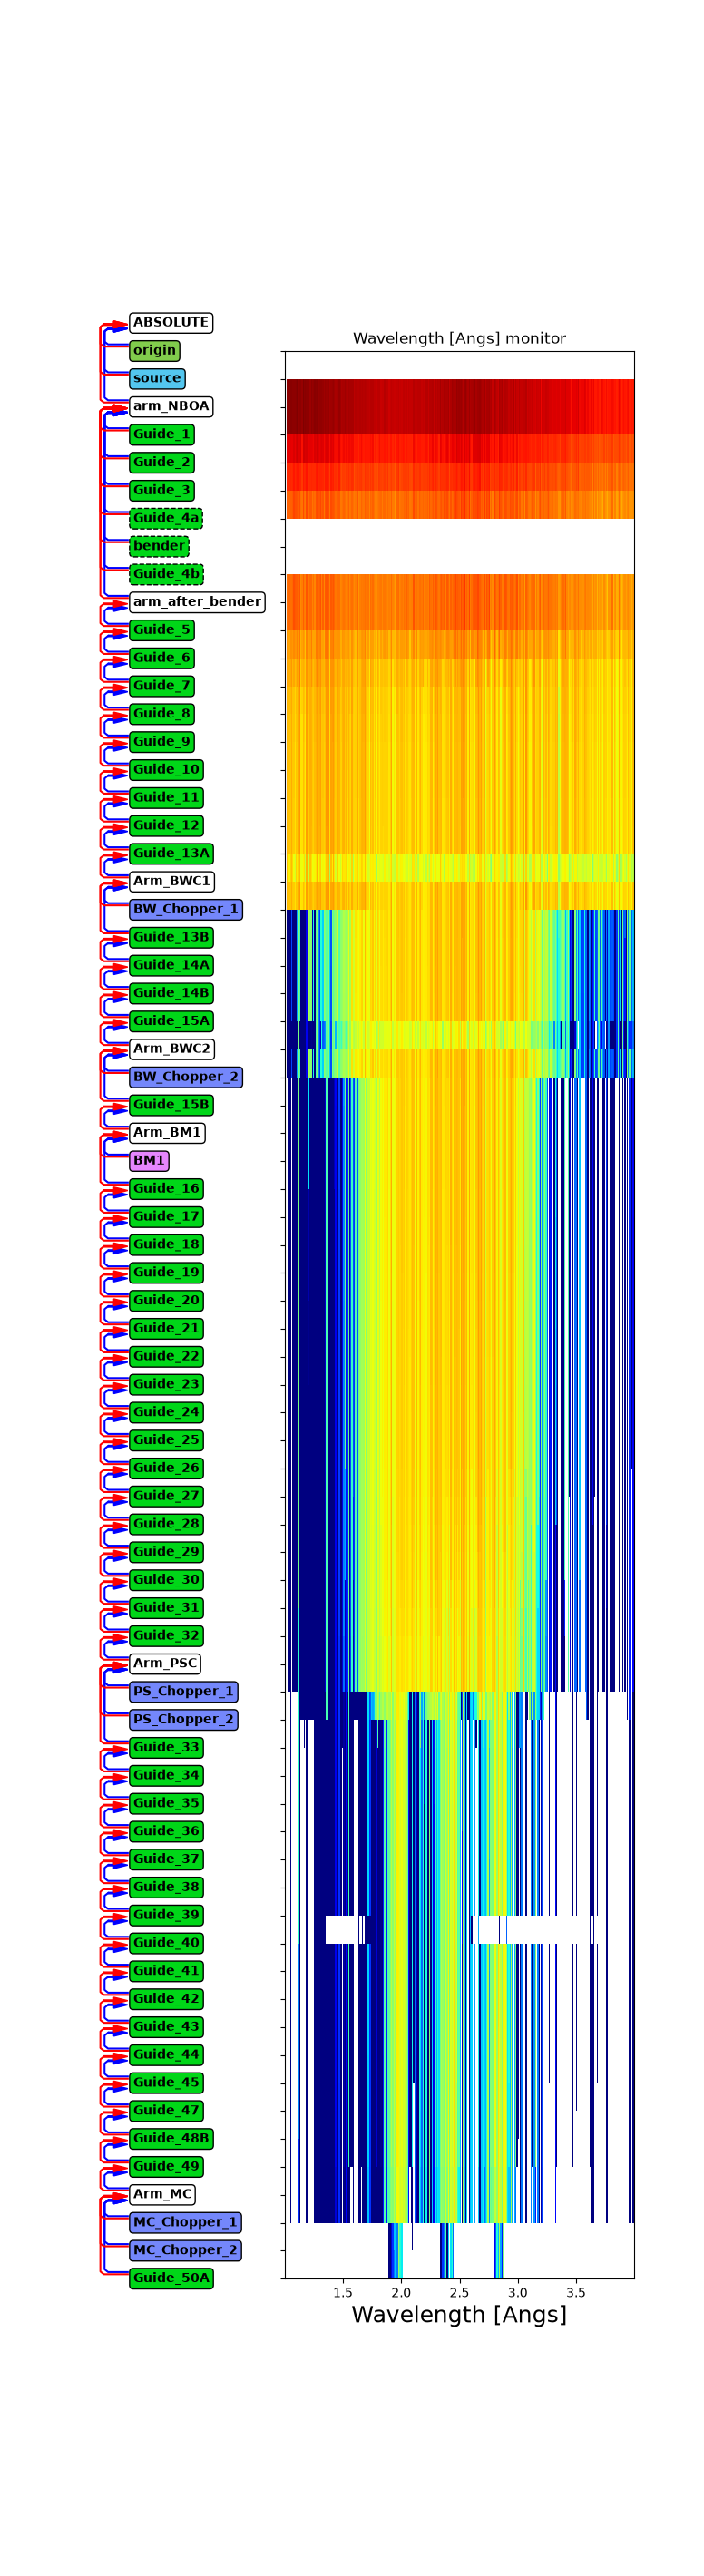

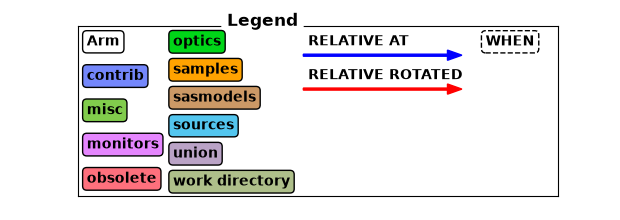

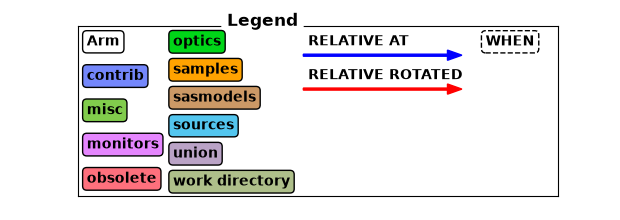

In [12]:
trex.set_parameters(bender=0)
trex.show_diagram(analysis=True)
trex.show_diagram(variable="l", limits=[1, 4])

# Diagnostics

In [13]:
diag = ms.Diagnostics(trex)

diag.settings(ncount=1e8, suppress_output=True, mpi="auto")
diag.show_settings()

Instrument settings:
  ncount:           1.00e+08
  mpi:              auto 
  output_path:      mcstas/out
  run_path:         ./mcstas
  package_path:     /Users/bingli/Documents/GitHub/mctrex/.pixi/envs/default/share/mcstas/resources
  executable_path:  /Users/bingli/Documents/GitHub/mctrex/.pixi/envs/default/bin
  executable:       mcrun
  force_compile:    True
  NeXus:            False
  save_comp_pars:   False


In [14]:
diag.clear_points()
diag.add_point(after="source")
diag.add_point(after="BW_Chopper_2")
diag.add_point(after="PS_Chopper_2")
diag.add_point(after="MC_Chopper_2")

In [15]:
diag.set_parameters(bender=0)
diag.show_parameters()

       L0      = 2.4        // wavelength in [Å] used to calculate the minimum 
                                and maximum wavelength for the source component by 
                                adding and subtracting a set wavelength 
int    RRM     = 4          // repetition rate multiplication
string mode    = "HF"       // HR for High Resolution, HF for High Flux
int    bender  = 0          // bender out = 0, bender in = 1
double b_rot   = -0.397881  // in [deg], rotation of the cold neutron bender = 
                                -atan(0.05/7.2), full deflection since endFlat=0 


In [16]:
diag.run()

In [28]:
diag.clear_views()
#diag.add_view("x", "y", bins=100, same_scale=True)
# diag.add_view("vx", "vy", bins=200)
# diag.add_view("dx", "dy", bins=100)
# diag.add_view("l", bins=100)
# diag.add_view("t", bins=100)
# diag.add_view("x", "l", bins=100, same_scale=True)
diag.add_view("t", "l", bins=[500,200], same_scale=True, top_lim=4, bottom_lim=1,left_lim=0.0,right_lim=0.15)
diag.add_view("t", bins=500,  same_scale=True,left_lim=0,right_lim=0.2)
diag.add_view("l", bins=200,  same_scale=True,left_lim=1,right_lim=4)


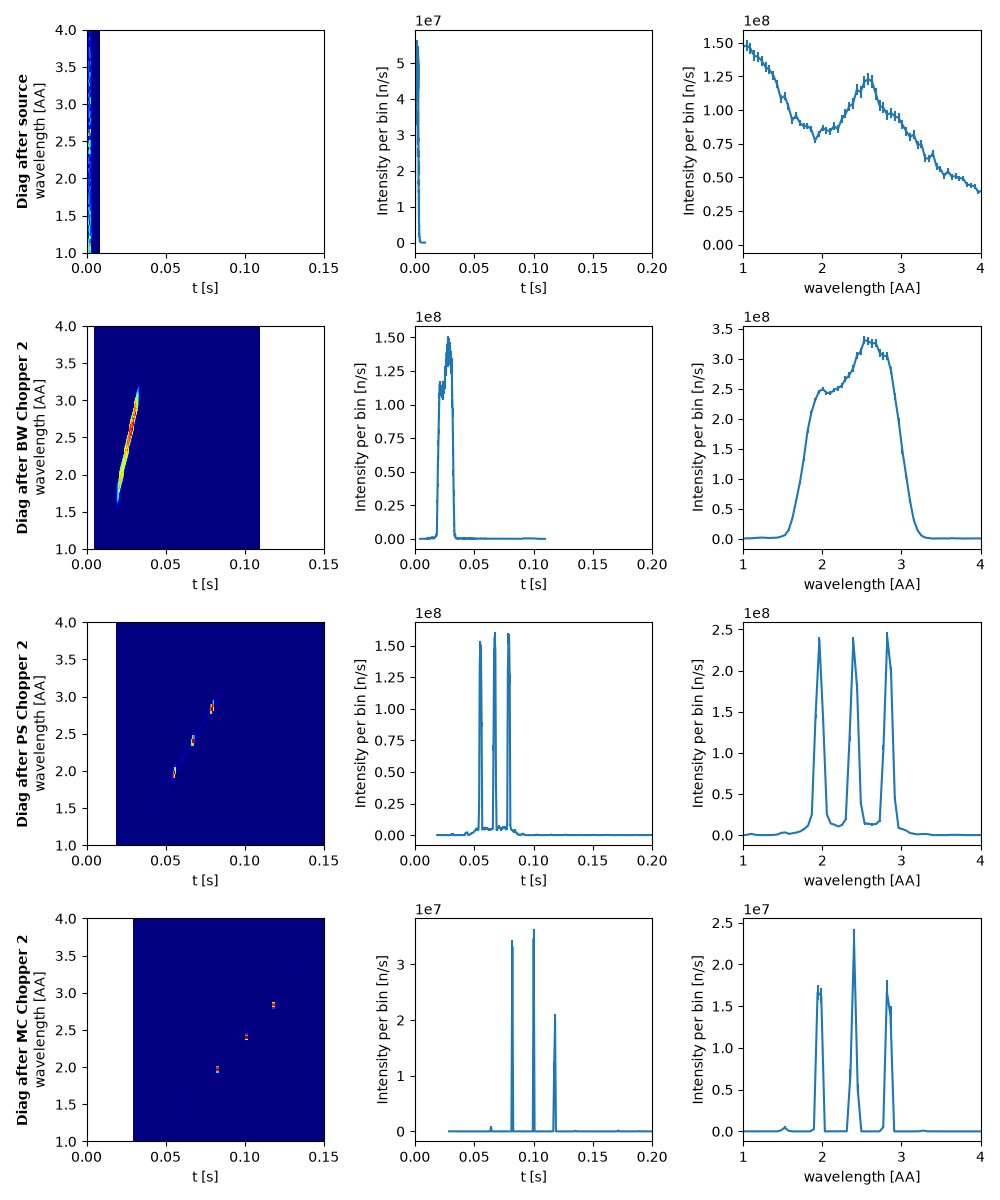

In [ ]:
#%matplotlib widget
%matplotlib inline
diag.plot()